In [1]:
import torch, gc

# Optional: delete large objects (like model, dataloader, etc.)
del optimizer
del dataloader
del dataset

# Force garbage collection
gc.collect()

# Clear PyTorch CUDA cache
torch.cuda.empty_cache()

# Reset CUDA memory stats (optional but useful)
torch.cuda.reset_peak_memory_stats()

print("✅ CUDA memory released and garbage collected.")

NameError: name 'optimizer' is not defined

In [1]:
import os
import json
from collections import defaultdict
from PIL import Image
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from accelerate import Accelerator
import shutil
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

C:\Users\Admin\anaconda3\envs\glide_yelp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
photos_dir = "photos"
json_path = "photos.json"
output_dir = "processed_yelp_images_strict_balanced"
os.makedirs(output_dir, exist_ok=True)

# Label settings
accepted_labels = {"food", "drink", "inside", "outside", "menu"}
original_label_counts = defaultdict(int)
balanced_label_counts = defaultdict(int)
selected_counts = defaultdict(int)

# First pass: count all labels
with open(json_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            if label in accepted_labels:
                original_label_counts[label] += 1
        except json.JSONDecodeError:
            continue

# Determine minimum count to balance
label_limit = min(original_label_counts[label] for label in accepted_labels)

print(f"Balancing to {label_limit} images per class.")
print("Label counts before balancing:")
for label in accepted_labels:
    print(f"{label}: {original_label_counts[label]}")

# Second pass: copy up to label_limit images per class
with open(json_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            photo_id = item.get("photo_id")

            if label not in accepted_labels:
                continue
            if selected_counts[label] >= label_limit:
                continue

            # Search for matching image file (any extension)
            for ext in [".jpg", ".jpeg", ".png"]:
                src_path = os.path.join(photos_dir, photo_id + ext)
                if os.path.isfile(src_path):
                    dest_path = os.path.join(output_dir, f"{label}_{photo_id}{ext}")
                    shutil.copyfile(src_path, dest_path)
                    selected_counts[label] += 1
                    break

        except json.JSONDecodeError:
            continue

# Print after balancing
print("\nLabel counts after balancing:")
for label in accepted_labels:
    print(f"{label}: {selected_counts[label]}")

Balancing to 1678 images per class.
Label counts before balancing:
inside: 56031
food: 108152
outside: 18569
menu: 1678
drink: 15670

Label counts after balancing:
inside: 1678
food: 1678
outside: 1678
menu: 1678
drink: 1678


### Label Mapping

In [3]:
captions = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            photo_id = item.get("photo_id")
            caption = item.get("caption", "").strip()

            if (
                label in accepted_labels and 
                caption and 
                any(os.path.exists(os.path.join(output_dir, f"{label}_{photo_id}{ext}")) for ext in [".jpg", ".jpeg", ".png"])
            ):
                captions.append({
                    "photo_id": photo_id,
                    "label": label,
                    "caption": caption
                })
        except json.JSONDecodeError:
            continue

# Save as CSV
caption_df = pd.DataFrame(captions)
caption_df.to_csv("caption_label_mapping.csv", index=False)
caption_df.head()


,photo_id,label,caption
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio


In [4]:
# Label-specific prompt templates
label_prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

# Create new column with prompts
caption_df["prompt"] = caption_df["label"].map(label_prompts)
caption_df.head()

,photo_id,label,caption,prompt
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...,An interior view of a restaurant with people a...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter,A high-quality image of a refreshing drink at ...
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi,A close-up photo of delicious food served at a...
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception,An interior view of a restaurant with people a...
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio,An outdoor shot of a restaurant building and e...


In [5]:
caption_df.to_csv("caption_prompt_mapping.csv", index=False)
print("Saved to caption_prompt_mapping.csv")

Saved to caption_prompt_mapping.csv


In [6]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import CLIPTokenizer
from torchvision import transforms
from tqdm import tqdm
import pandas as pd
from accelerate import Accelerator


### Dataset

In [7]:
import pandas as pd
import os

df = pd.read_csv("caption_prompt_mapping.csv")

# Add full image paths based on label and photo_id
def get_image_path(row):
    base = f"{row['label']}_{row['photo_id']}"
    for ext in [".jpg", ".jpeg", ".png"]:
        path = os.path.join("processed_yelp_images_strict_balanced", base + ext)
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df.apply(get_image_path, axis=1)
df = df[df["image_path"].notnull()].reset_index(drop=True)
df.head()

,photo_id,label,caption,prompt,image_path
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...,An interior view of a restaurant with people a...,processed_yelp_images_strict_balanced\inside_z...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter,A high-quality image of a refreshing drink at ...,processed_yelp_images_strict_balanced\drink_vk...
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi,A close-up photo of delicious food served at a...,processed_yelp_images_strict_balanced\food_pve...
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception,An interior view of a restaurant with people a...,processed_yelp_images_strict_balanced\inside_3...
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio,An outdoor shot of a restaurant building and e...,processed_yelp_images_strict_balanced\outside_...


In [8]:
from diffusers import StableDiffusionPipeline
from peft import get_peft_model, LoraConfig, TaskType
from accelerate import Accelerator
import torch

accelerator = Accelerator()
device = accelerator.device

pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32,  # safer for torch <2.6
    safety_checker=None
).to(device)

pipe.unet.requires_grad_(False)
pipe.vae.requires_grad_(False)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
)

pipe.text_encoder = get_peft_model(pipe.text_encoder, lora_config)
pipe.text_encoder.print_trainable_parameters()

Loading pipeline components...: 100%|████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.96it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


trainable params: 753,664 || all params: 341,141,504 || trainable%: 0.2209


In [9]:
from transformers import CLIPTokenizer
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

class YelpText2ImageDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_size=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        text = self.tokenizer(
            row["caption"],  # ← use actual caption text
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": text.input_ids.squeeze(0),
            "attention_mask": text.attention_mask.squeeze(0),
            "label": row["label"]
        }

dataset = YelpText2ImageDataset(df, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

### Model

Single epoch

In [10]:
from tqdm import tqdm
import torch
import torch.nn.functional as F

pipe.unet.train()
pipe.text_encoder.train()

# Optimizer for both UNet and text encoder (you can adjust if you want only text_encoder)
optimizer = torch.optim.AdamW(
    list(pipe.unet.parameters()) + list(pipe.text_encoder.parameters()), 
    lr=1e-5
)

for step, batch in enumerate(tqdm(dataloader, desc="Training", dynamic_ncols=True, leave=False)):
    pixel_values = batch["pixel_values"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    # Encode images into latent space
    latents = pipe.vae.encode(pixel_values).latent_dist.sample()
    latents = latents * 0.18215

    # Sample random timesteps
    timesteps = torch.randint(
        0, pipe.scheduler.config.num_train_timesteps, 
        (latents.shape[0],), device=device
    ).long()

    # Add noise
    noise = torch.randn_like(latents)
    noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

    # Text encoder (with PEFT adapter)
    encoder_hidden_states = pipe.text_encoder.base_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).last_hidden_state

    # Predict noise with UNet
    noise_pred = pipe.unet(
        noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states
    ).sample

    # MSE Loss
    loss = F.mse_loss(noise_pred, noise)

    # Backpropagation
    optimizer.zero_grad()
    accelerator.backward(loss)
    optimizer.step()

    if step % 100 == 0:
        print(f"\rStep {step}: Loss = {loss.item():.4f}", end="", flush=True)

Training:   0%|                                                                               | 0/2038 [00:00<?, ?it/s]

Step 0: Loss = 0.3269

Training:   5%|███▍                                                                 | 100/2038 [00:31<09:59,  3.23it/s]

Step 100: Loss = 0.2235

Training:  10%|██████▊                                                              | 200/2038 [01:00<08:46,  3.49it/s]

...

Step 1800: Loss = 0.2473

Training:  93%|███████████████████████████████████████████████████████████████▍    | 1900/2038 [09:05<00:37,  3.68it/s]

Step 1900: Loss = 0.2007

Training:  98%|██████████████████████████████████████████████████████████████████▋ | 2000/2038 [09:33<00:10,  3.74it/s]

Step 2000: Loss = 0.2865

Multiple epochs

In [11]:
import os
import torch
from tqdm import tqdm
import torch.nn.functional as F

# Training hyperparameters
epochs = 5
lr = 1e-5
save_steps = 500
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

In [12]:
# Set model components to train mode
pipe.unet.train()
pipe.text_encoder.train()

# Optimizer: UNet + text encoder
optimizer = torch.optim.AdamW(
    list(pipe.unet.parameters()) + list(pipe.text_encoder.parameters()),
    lr=lr
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

In [14]:
global_step = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    for step, batch in enumerate(tqdm(dataloader, desc="Training", dynamic_ncols=True, leave=False)):
        pipe.unet.train()
        pipe.text_encoder.train()

        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        latents = pipe.vae.encode(pixel_values).latent_dist.sample() * 0.18215

        timesteps = torch.randint(
            0, pipe.scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=device
        ).long()
        noise = torch.randn_like(latents)
        noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

        encoder_hidden_states = pipe.text_encoder.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        noise_pred = pipe.unet(
            noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states
        ).sample

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        accelerator.backward(loss)
        optimizer.step()
        scheduler.step()

        if global_step % 1000 == 0:
            print(f"\rEpoch {epoch + 1}, Step {global_step}: Loss = {loss.item():.4f}", end="", flush=True)
        
        # Save checkpoint only
        if global_step % save_steps == 0 and global_step != 0:
            checkpoint_path = os.path.join(save_dir, f"checkpoint_step{global_step}")
            pipe.save_pretrained(checkpoint_path)
            print(f"\nSaved checkpoint at step {global_step} to {checkpoint_path}")

        global_step += 1



Epoch 1/5


Training:   0%|                                                                               | 0/2038 [00:00<?, ?it/s]

Epoch 1, Step 0: Loss = 0.2090

self.text_encoder=PeftModelForFeatureExtraction(                                    | 500/2038 [02:32<08:23,  3.05it/s]
  (base_model): LoraModel(
    (model): CLIPTextModel(
      (text_model): CLIPTextTransformer(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 1024)
          (position_embedding): Embedding(77, 1024)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-22): 23 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_features=8, bias=False)
                  )



Saved checkpoint at step 500 to checkpoints\checkpoint_step500


...


Saved checkpoint at step 9500 to checkpoints\checkpoint_step9500


Training:  91%|█████████████████████████████████████████████████████████████▋      | 1848/2038 [09:18<00:57,  3.28it/s]

Epoch 5, Step 10000: Loss = 0.2308

self.text_encoder=PeftModelForFeatureExtraction(
  (base_model): LoraModel(
    (model): CLIPTextModel(
      (text_model): CLIPTextTransformer(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 1024)
          (position_embedding): Embedding(77, 1024)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-22): 23 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): 


Saved checkpoint at step 10000 to checkpoints\checkpoint_step10000


In [25]:
from torchvision import transforms as T
from diffusers import EulerDiscreteScheduler


pipe.unet.eval()
pipe.text_encoder.eval()
pipe.vae.eval()

eval_dir = os.path.join(save_dir, f"eval_samples_step{global_step}")
os.makedirs(eval_dir, exist_ok=True)

prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

transform = T.ToPILImage()
num_inference_steps = 50

with torch.no_grad():
    for label, prompt in prompts.items():
        # Re-init scheduler every time to reset internal state
        pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
        pipe.scheduler.set_timesteps(num_inference_steps)
        timesteps = pipe.scheduler.timesteps

        # Tokenize
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        prompt_embeds = pipe.text_encoder.base_model(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask
        ).last_hidden_state

        # Latent noise
        latents = torch.randn((1, pipe.unet.in_channels, 64, 64), device=device)
        latents = latents * pipe.scheduler.init_noise_sigma

        # Denoising loop
        for t in timesteps[:-1]:
            latent_model_input = pipe.scheduler.scale_model_input(latents, t)
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode
        image = pipe.vae.decode(latents / 0.18215).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image_pil = transform(image.squeeze().cpu())
        image_pil.save(os.path.join(eval_dir, f"{label}.jpg"))
        print(f"Saved {label} sample.")


Saved food sample.
Saved drink sample.
Saved inside sample.
Saved outside sample.
Saved menu sample.


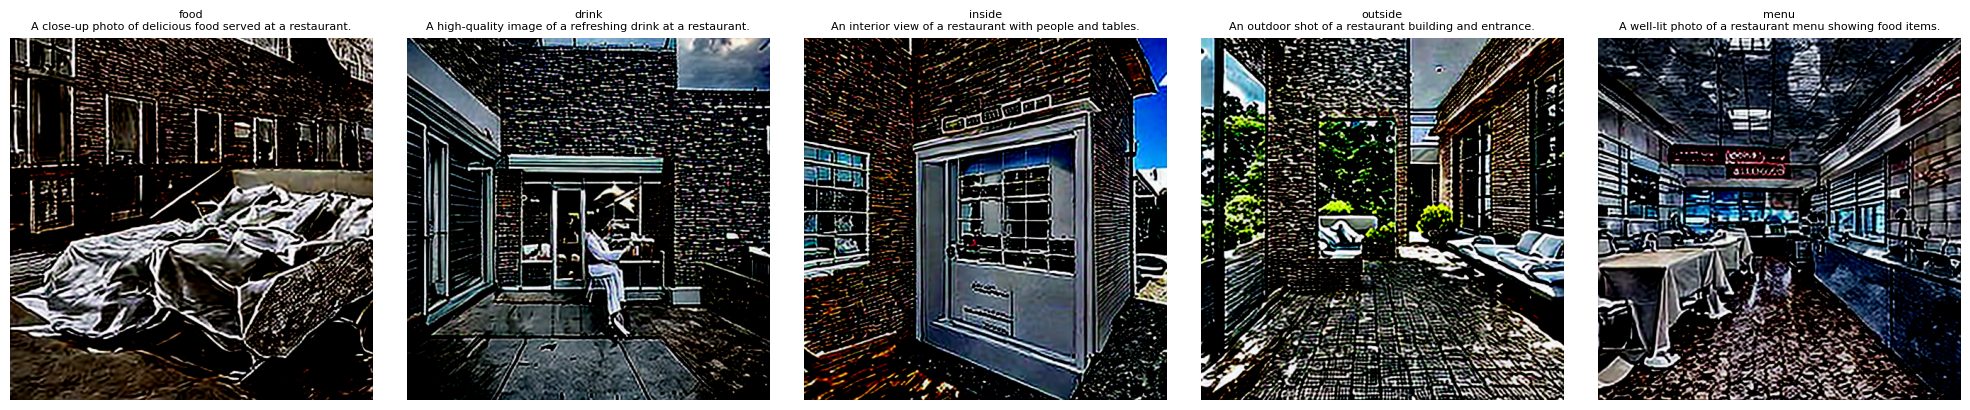

In [38]:
import torch
from transformers import CLIPTokenizer
from diffusers import EulerDiscreteScheduler
import matplotlib.pyplot as plt

# Use the tokenizer (already available from pipeline)
tokenizer = pipe.tokenizer

# Prompts per label
prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

# Setup plot
fig, axs = plt.subplots(1, len(prompts), figsize=(20, 4))

# Disable grad
pipe.text_encoder.eval()
pipe.unet.eval()
pipe.vae.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for i, (label, prompt) in enumerate(prompts.items()):
        # Tokenize and encode prompt
        tokens = tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=77)
        input_ids = tokens.input_ids.to(device)
        attention_mask = tokens.attention_mask.to(device)

        prompt_embeds = pipe.text_encoder.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        # Reset scheduler
        pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
        pipe.scheduler.set_timesteps(50, device=device)

        # Generate initial latents
        latents = torch.randn((1, pipe.unet.in_channels, pipe.unet.sample_size, pipe.unet.sample_size)).to(device)
        latents = latents * pipe.scheduler.init_noise_sigma

        # Denoising loop
        for t in pipe.scheduler.timesteps:
            latent_model_input = pipe.scheduler.scale_model_input(latents, t)
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode latents
        image = pipe.vae.decode(latents / 0.18215).sample[0]
        image = image.clamp(0, 1).cpu().permute(1, 2, 0).numpy()

        axs[i].imshow(image)
        axs[i].axis("off")
        axs[i].set_title(f"{label}\n{prompt}", fontsize=8)

plt.tight_layout()
plt.show()
